###**Carregando dados e configurando gráficos**

In [1]:
from google.colab import drive
import matplotlib.pyplot as plt
import os
import pandas as pd
import seaborn as sns

drive.mount("/content/drive")
%cd /content/drive/MyDrive/cafeicultura-varginha-analytics

# Carrega dataset diário com features
df_diario = pd.read_csv("data/processed/varginha_diario_features.csv")
df_diario["data"] = pd.to_datetime(df_diario["data"])

# Cria pasta para salvar gráficos
os.makedirs("reports/figures", exist_ok=True)

# Estilo dos gráficos
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

Mounted at /content/drive
/content/drive/MyDrive/cafeicultura-varginha-analytics


###**Sazonalidade de Temperatura, Chuva e Estresse Térmico**

/tmp/ipykernel_707/3084910310.py:14: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df_mensal, x="mes", y="precipitacao_total", ax=axes[1], ci=None, color="skyblue")
/tmp/ipykernel_707/3084910310.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[2].set_xticklabels(axes[2].get_xticklabels(), rotation=45)


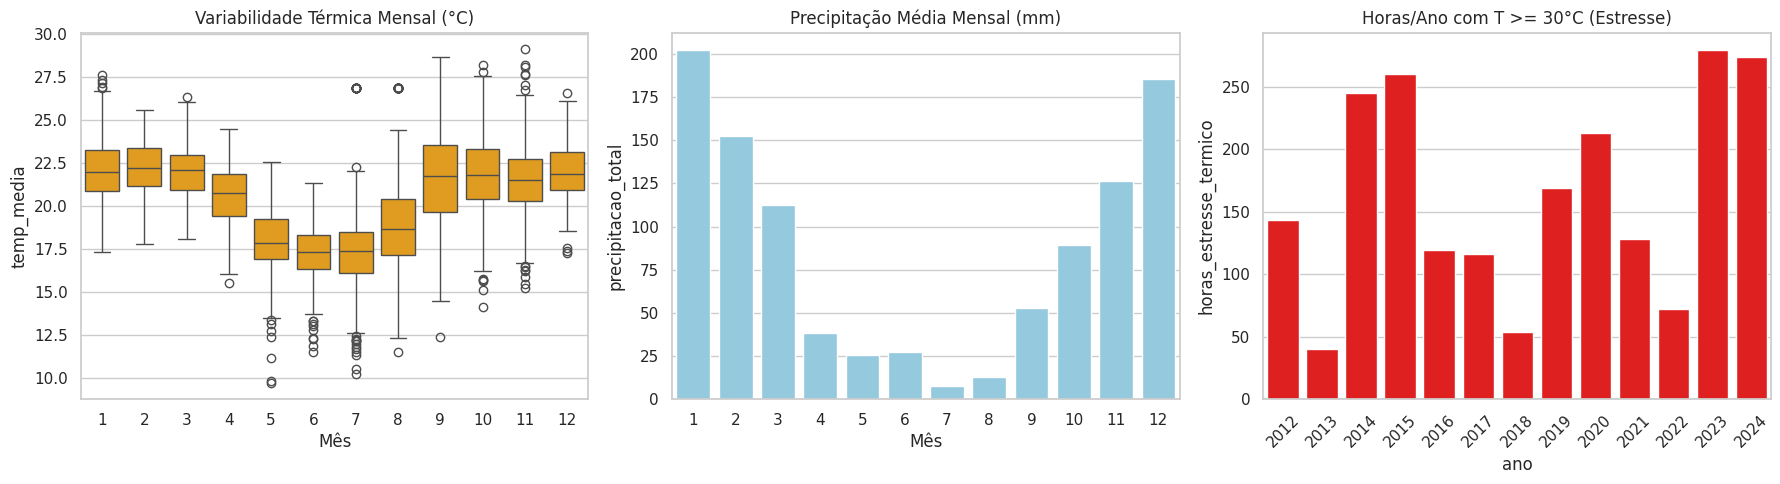

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Temperatura Média Mensal
sns.boxplot(
    data=df_diario, x="mes", y="temp_media", ax=axes[0], color="orange"
)
axes[0].set_title("Variabilidade Térmica Mensal (°C)")
axes[0].set_xlabel("Mês")

# 2. Chuva Total Mensal Média
df_mensal = (
    df_diario.groupby(["ano", "mes"])["precipitacao_total"].sum().reset_index()
)
sns.barplot(data=df_mensal, x="mes", y="precipitacao_total", ax=axes[1], ci=None, color="skyblue")
axes[1].set_title("Precipitação Média Mensal (mm)")
axes[1].set_xlabel("Mês")

# 3. Horas de Estresse Térmico por Ano (T >= 30°C)
df_anual = (
    df_diario.groupby("ano")["horas_estresse_termico"].sum().reset_index()
)
sns.barplot(
    data=df_anual, x="ano", y="horas_estresse_termico", ax=axes[2], color="red"
)
axes[2].set_title("Horas/Ano com T >= 30°C (Estresse)")
axes[2].set_xticklabels(axes[2].get_xticklabels(), rotation=45)

plt.tight_layout()
plt.savefig("reports/figures/eda_panorama_bioclimatico.png", dpi=300)
plt.show()

In [ ]:
!git add 03_eda_visualizacao.ipynb reports/figures/
!git commit -m "feat: adiciona eda com visualizacoes de temperatura, precipitação e estresse termico"
!git push origin main